### IMEC2543 - DINAMICA DE MAQUINARIA
### [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/) Cod. 202321287
# Taller 1

In [1]:
import numpy as np
from numpy import deg2rad, rad2deg
from sympy import symbols, pi, sin, cos, lambdify, solve, linear_eq_to_matrix, simplify, acos, sqrt, rad
import sympy as sp
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, express
from scipy import optimize
from scipy.optimize import fsolve
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

### Nota: Todos los recursos para esta actividad se pueden encontrar en el siguiente github, hay cosas que no adjunte como imagenes adicionales y mediciones que se encuentran aquí: https://github.com/LuigiToby/IMEC2543/tree/main/talleres/taller1

# Paso -1 — Estrategia

## Metodología

1. Modelar el RR en Python  
   - FK, IK  
   - Geometría de eslabones  
   - Obstáculo equivalente a MuJoCo  

2. Analizar restricciones del problema  
   - Giro 360° horario  
   - Efector final detrás del cubo  
   - Codo por encima del cubo  

3. Definir key-points  
   - Configuración inicial  
   - Puntos intermedios  
   - Configuración final  

4. Generar trayectoria (fase libre)  
   - Interpolación en joint space  
   - Perfiles suaves  

5. Planificación con restricción  
   - FK para evaluar posiciones  
   - Chequeo de colisión de eslabones  
   - Ajuste de trayectoria sin colisiones  

6. Construir trayectoria completa  
   - Unir fases  
   - Verificar continuidad y validez  

7. Exportar a MuJoCo  
   - Definir $q_1(t)$, $q_2(t)$)  
   - Ejecutar con PID  

8. Validación  
   - Sin colisiones  
   - Movimiento completo correcto  

# Paso 0 - Crear robot RR
Este robot ya fue un bono de clase, entonces lo reciclo de este bono

In [2]:
# Simbolos
AB, BC, CD= symbols('AB, BC, CD') 
# Simbolos dinámicos
theta1, theta2 = dynamicsymbols('theta1 theta2')
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [theta1, N.z])
B = A.orientnew('B', 'Axis', [theta2, N.z])

params={AB:0.7,BC:0.7}

radiol1 = 0.025
radiol2 = 0.022

obs_center = (0.5, 0.2)
obs_half = (0.10, 0.10)

x_min, x_max = 0.4, 0.6
y_min, y_max = 0.1, 0.3

r1 = AB*A.x
r2 = BC*B.x

eqLoop = r1+r2

eqParams = eqLoop.subs(params)

eq_fun = lambdify(
    [theta1, theta2],
    [eqParams.dot(N.x), eqParams.dot(N.y)]
)

display(eqLoop)
display(eqParams)
display([eqParams.dot(N.x), eqParams.dot(N.y)])

AB*A.x + BC*B.x

0.7*A.x + 0.7*B.x

[-0.7*sin(theta1(t))*sin(theta2(t)) + 0.7*cos(theta1(t))*cos(theta2(t)) + 0.7*cos(theta1(t)),
 0.7*sin(theta1(t))*cos(theta2(t)) + 0.7*sin(theta1(t)) + 0.7*sin(theta2(t))*cos(theta1(t))]

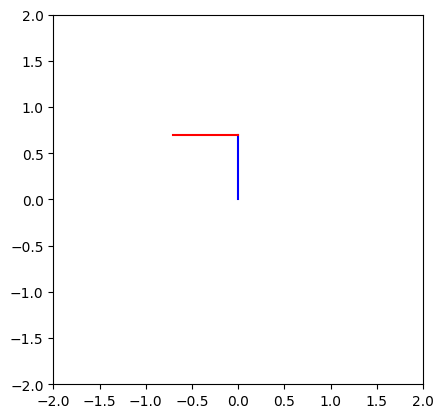

In [3]:
points={'A':0*N.x,'B':r1,'C':r1+r2}
points_fun={k:lambdify([theta1,theta2],[v.dot(N.x).subs(params),v.dot(N.y).subs(params)]) for k,v in points.items()}
# Esta función de aquí se ve complicada, pero en realidad es bastante bonita, entonces esta función
# se encarga de crear un diccionario de funciones numéricas para cada punto del mecanismo
# Cada función recibe los ángulos y la posición x de OR y devuelve las coordenadas x e y del punto correspondiente

def plotMechanism(joint_values,ax=None):    
    A=points_fun['A'](*joint_values) # Operador de unpacking, es decir, toma la lista de joint_values y los pasa como argumentos a la función de cada punto
    B=points_fun['B'](*joint_values)
    C=points_fun['C'](*joint_values)
    if ax is None:
        ax=plt.figure().add_subplot(111)
    ax.plot([A[0],B[0]], [A[1],B[1]], 'BLUE')
    ax.plot([B[0],C[0]], [B[1],C[1]], 'red')
    ax.set_aspect('equal')
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)

# Example with some arbitrary joint values

plotMechanism([np.deg2rad(90),np.deg2rad(90)])

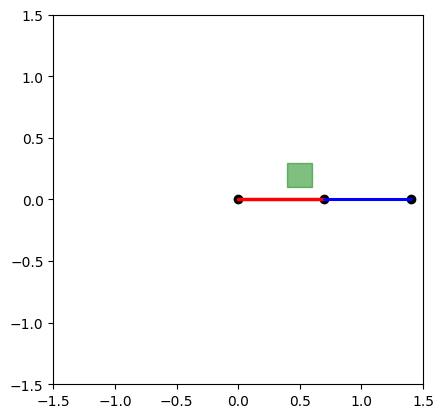

In [4]:
def plotMechanism2(joint_values, ax=None):
    A = np.array(points_fun['A'](*joint_values))
    B = np.array(points_fun['B'](*joint_values))
    C = np.array(points_fun['C'](*joint_values))

    if ax is None:
        fig, ax = plt.subplots()

    # --- LINK 1 ---
    ax.plot(
        [A[0], B[0]],
        [A[1], B[1]],
        linewidth=radiol1 * 100,   # escala visual
        color='red',
        solid_capstyle='round'
    )

    # --- LINK 2 ---
    ax.plot(
        [B[0], C[0]],
        [B[1], C[1]],
        linewidth=radiol2 * 100,
        color='blue',
        solid_capstyle='round'
    )

    # --- OBSTÁCULO ---
    rect = Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        color='green',
        alpha=0.5
    )
    ax.add_patch(rect)

    # --- JOINTS ---
    ax.scatter(A[0], A[1], color='black')
    ax.scatter(B[0], B[1], color='black')
    ax.scatter(C[0], C[1], color='black')

    ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    
plotMechanism2([np.deg2rad(0),np.deg2rad(0)])

In [33]:
def FK(q):
    return np.array(eq_fun(q[0], q[1]))

def IK_error(q, target):
    return np.square(FK(q) - target).sum()

def IK(target):
    seeds = [
        # [0, 0],
        # [-np.pi/2, 0.5],
        # [-np.pi, 0.5],
        [np.pi/2, np.pi/2]
        # [-2.5, 0.5]
    ]

    best_q = None
    best_err = np.inf

    for q0 in seeds:
        res = minimize(
            IK_error,
            args=(target,),
            x0=q0,
            method='L-BFGS-B'
        )

        err = IK_error(res.x, target)

        if err < best_err:
            best_err = err
            best_q = res.x

    return best_q, best_err

FK: [ 1.00000001e+00 -5.36473432e-09]
Error: 1.7190071181044442e-16
[-5.50799195  4.73279858]


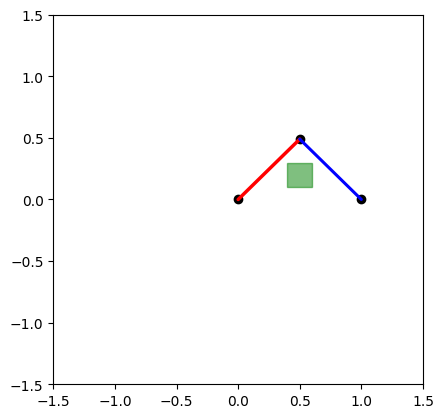

In [35]:
le_point = np.array([1,0])

qstar, err = IK(le_point)

print("FK:", FK(qstar))
print("Error:", err)
print(qstar)
plotMechanism2([qstar[0], qstar[1]])

In [6]:
import numpy as np

t = np.linspace(0, 1, 100)

traj_q = []

for s in t:
    q1 = 0 - np.pi * s      # de 0 → -π (movimiento horizontal)
    q2 = 0            # fijo (codo arriba)

    traj_q.append([q1, q2])

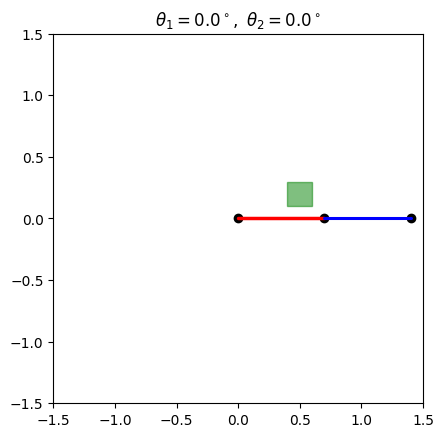

In [7]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots()

def update(i):
    ax.clear()

    # trayectoria real
    q1, q2 = traj_q[i]

    joint_values = [q1, q2]

    plotMechanism2(joint_values, ax)

    ax.set_title(
        rf"$\theta_1={np.rad2deg(q1):.1f}^\circ,\ "
        rf"\theta_2={np.rad2deg(q2):.1f}^\circ$"
    )

    ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(traj_q),
    interval=80,
    repeat=False,
)

HTML(anim.to_jshtml())

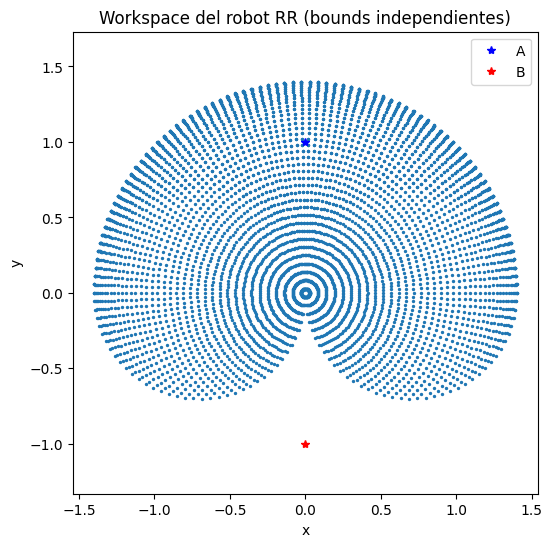

In [47]:
# Rangos independientes
theta1_vals = np.deg2rad(np.linspace(0, 180, 80))     # joint 1
theta2_vals = np.deg2rad(np.linspace(0, 360, 80))  # joint 2

# Grid en espacio de joints
th1_grid, th2_grid = np.meshgrid(theta1_vals, theta2_vals)

# almacenar posiciones del efector final
x_vals = np.zeros_like(th1_grid)
y_vals = np.zeros_like(th2_grid)

for i in range(th1_grid.shape[0]):
    for j in range(th1_grid.shape[1]):
        q1 = th1_grid[i, j]
        q2 = th2_grid[i, j]

        C = points_fun['C'](q1, q2)
        x_vals[i, j] = C[0]
        y_vals[i, j] = C[1]

# plot workspace
plt.figure(figsize=(6,6))
plt.scatter(x_vals.flatten(), y_vals.flatten(), s=2)

# puntos de referencia
pos_A = [0, 1.0]
pos_B = [0, -1.0]

plt.plot(*pos_A, 'b*', label='A')
plt.plot(*pos_B, 'r*', label='B')

plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Workspace del robot RR (bounds independientes)')
plt.legend()
plt.show()

In [48]:
def segment_box_collision(P, Q, radius=0.0):
    # Inflar la caja
    x0 = x_min - radius
    x1 = x_max + radius
    y0 = y_min - radius
    y1 = y_max + radius

    # 1. Si algún punto está dentro → colisión
    if (x0 <= P[0] <= x1 and y0 <= P[1] <= y1) or \
       (x0 <= Q[0] <= x1 and y0 <= Q[1] <= y1):
        return True

    # 2. Definir función de intersección segmento-segmento
    def ccw(A, B, C):
        return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])

    def intersect(A, B, C, D):
        return ccw(A,C,D) != ccw(B,C,D) and ccw(A,B,C) != ccw(A,B,D)

    # 3. Bordes del rectángulo
    rect_edges = [
        ((x0,y0),(x1,y0)),
        ((x1,y0),(x1,y1)),
        ((x1,y1),(x0,y1)),
        ((x0,y1),(x0,y0))
    ]

    # 4. Chequear intersección con cada borde
    for E1, E2 in rect_edges:
        if intersect(P, Q, E1, E2):
            return True

    return False

def checkValidity(q1, q2):
    A = np.array(points_fun['A'](q1, q2))
    B = np.array(points_fun['B'](q1, q2))
    C = np.array(points_fun['C'](q1, q2))

    if segment_box_collision(A, B, radiol1):
        return False

    if segment_box_collision(B, C, radiol2):
        return False

    return True

In [51]:
# Rangos independientes
theta1_vals = np.deg2rad(np.linspace(0, 180, 100))
theta2_vals = np.deg2rad(np.linspace(0, 360, 100))

th1_grid, th2_grid = np.meshgrid(theta1_vals, theta2_vals)

# almacenar workspace
x_vals = np.zeros_like(th1_grid)
y_vals = np.zeros_like(th2_grid)

# almacenar configuraciones válidas
valid_configs = []   # ← esto es lo importante
valid_x = []
valid_y = []

invalid_x = []
invalid_y = []

for i in range(th1_grid.shape[0]):
    for j in range(th1_grid.shape[1]):
        q1 = th1_grid[i, j]
        q2 = th2_grid[i, j]

        # FK
        C = points_fun['C'](q1, q2)
        x_vals[i, j] = C[0]
        y_vals[i, j] = C[1]

        # check colisión
        if checkValidity(q1, q2):
            valid_configs.append([q1, q2])
            valid_x.append(C[0])
            valid_y.append(C[1])
        else:
            invalid_x.append(C[0])
            invalid_y.append(C[1])

valid_configs = np.array(valid_configs)

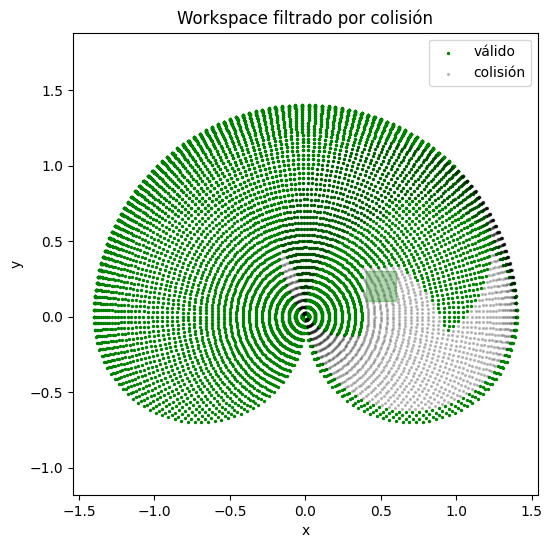

In [52]:
plt.figure(figsize=(6,6))

# válidos
plt.scatter(valid_x, valid_y, s=2, color='green', label='válido')

# inválidos
plt.scatter(invalid_x, invalid_y, s=2, color='black', alpha=0.2, label='colisión')

# obstáculo
from matplotlib.patches import Rectangle
rect = Rectangle((x_min, y_min),
                 x_max - x_min,
                 y_max - y_min,
                 color='green', alpha=0.3)
plt.gca().add_patch(rect)

plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Workspace filtrado por colisión')
plt.legend()
plt.show()

In [36]:
import numpy as np
from pathfinding.core.grid import Grid
from pathfinding.finder.a_star import AStarFinder

# --- límites del espacio (ajústalos si quieres recortar) ---
theta1_vals = np.linspace(-2*np.pi, 0, 120)
theta2_vals = np.linspace(0, np.pi, 120)

# grid
valid_grid = np.zeros((len(theta2_vals), len(theta1_vals)))

# construir mapa de validez
for i, q2 in enumerate(theta2_vals):
    for j, q1 in enumerate(theta1_vals):
        if checkValidity(q1, q2):
            valid_grid[i, j] = 1

# --- start y goal ---
q_start = np.array([-np.pi, 0.0])
q_goal  = np.array([-5.50799195, 4.73279858])

# función para mapear q → índice
def q_to_idx(q1, q2):
    j = np.argmin(np.abs(theta1_vals - q1))
    i = np.argmin(np.abs(theta2_vals - q2))
    return i, j

start_i, start_j = q_to_idx(q_start[0], q_start[1])
goal_i,  goal_j  = q_to_idx(q_goal[0],  q_goal[1])

# --- A* ---
grid = Grid(matrix=valid_grid)
start = grid.node(start_j, start_i)
end   = grid.node(goal_j, goal_i)

finder = AStarFinder()
path, _ = finder.find_path(start, end, grid)

# convertir a trayectoria continua
traj_q = []
for node in path:
    j, i = node.x, node.y
    q1 = theta1_vals[j]
    q2 = theta2_vals[i]
    traj_q.append([q1, q2])

traj_q = np.array(traj_q)

print("Trayectoria encontrada:", len(traj_q), "puntos")

Trayectoria encontrada: 164 puntos


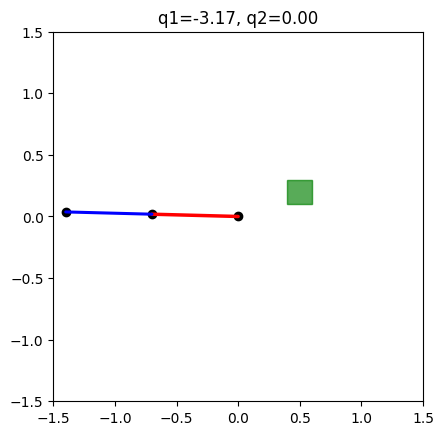

In [37]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots()

def update(i):
    ax.clear()

    q1, q2 = traj_q[i]

    plotMechanism2([q1, q2], ax)

    # dibujar obstáculo
    from matplotlib.patches import Rectangle
    rect = Rectangle((x_min, y_min),
                     x_max - x_min,
                     y_max - y_min,
                     color='green', alpha=0.3)
    ax.add_patch(rect)

    ax.set_title(f"q1={q1:.2f}, q2={q2:.2f}")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(traj_q),
    interval=50,
)

HTML(anim.to_jshtml())